# 💰 Notebook 6 — Final Premium

**Goal:** Compute the final commercial premium for every policy in the historical dataset.

$$\text{Final Premium} = \underbrace{\mathbb{E}[\text{Freq}] \times \mathbb{E}[\text{Sev}]}_{\text{Pure Premium}} \times \underbrace{L}_{\text{Large Loss Loading}} \times \underbrace{\text{RAF}}_{\text{Risk Adj Factor}} \times \underbrace{1.05}_{\text{Profit Margin}}$$

**Input:** `outputs/df_with_adj.parquet` · `outputs/meta.json`

**Output:** `outputs/df_final_premiums.parquet` · `outputs/FINAL_priced.xlsx` · `outputs/pricing_registry.json`

---

## 6.1 — Load Data & Set Parameters

👇 **Tune the final pricing parameters here:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, pickle, warnings
warnings.filterwarnings('ignore')

df   = pd.read_parquet('../outputs/df_with_adj.parquet')
meta = json.load(open('../outputs/meta.json'))

CLAIM_COUNT_COL  = meta['claim_count_col']
CLAIM_AMOUNT_COL = meta['claim_amount_col']

# ─── TUNE THESE ────────────────────────────────────────────────────────────
PROFIT_MARGIN      = 1.05    # 5% profit margin
LARGE_LOSS_LOADING = 1.10    # 10% loading for large/catastrophic losses
                                                                            # EXPENSES = 1.30    # For the Underwriting & all other expenses
PREMIUM_FLOOR      = 50.0    # Minimum premium per policy
PREMIUM_CAP        = 5000.0  # Maximum premium per policy
# ───────────────────────────────────────────────────────────────────────────

print(f'Dataset: {len(df):,} rows')

Dataset: 111,615 rows


## 6.2 — Compute Final Premium

In [2]:
def tool_calculate_commercial_premium(df, pure_prem_col, risk_adj_col, large_loss_loading=1.10, profit_margin=1.05, floor=50.0, cap=5000.0):
    """
    Executes the Commercial Pricing Equation to compute final customer premiums.
    
    What this tool does:
        Multiplies modeled pure premium by catastrophic loading, credibility adjustment, and
        profit margin, enforcing regulatory rate floors and ceiling caps.
        
    Returns:
        tuple: (df_priced, summary_stats_dict)
    """
    gross = df[pure_prem_col] * large_loss_loading * df[risk_adj_col] * profit_margin
    df['Final_Premium'] = gross.clip(lower=floor, upper=cap)
    
    stats = {
        'mean_pure_prem':   float(df[pure_prem_col].mean()),
        'mean_raf':         float(df[risk_adj_col].mean()),
        'mean_final_prem':  float(df['Final_Premium'].mean()),
        'median_final_prem':float(df['Final_Premium'].median()),
        'total_revenue':    float(df['Final_Premium'].sum()),
        'pct_at_floor':     float((gross < floor).mean() * 100),
        'pct_at_cap':       float((gross > cap).mean() * 100)
    }
    return df, stats

# ── Run Execution ─────────────────────────────────────────────────────────────
df, prem_stats = tool_calculate_commercial_premium(
    df, 'PurePremium_Model', 'Risk_Adj_Factor',
    large_loss_loading=LARGE_LOSS_LOADING,
    profit_margin=PROFIT_MARGIN,
    floor=PREMIUM_FLOOR,
    cap=PREMIUM_CAP
)

print('=== Portfolio Summary ===')
print(f"Pure Premium (mean)   : {prem_stats['mean_pure_prem']:.2f}")
print(f"Risk Adj Factor (mean): {prem_stats['mean_raf']:.4f}")
print(f"Final Premium (mean)  : {prem_stats['mean_final_prem']:.2f}")
print(f"Final Premium (median): {prem_stats['median_final_prem']:.2f}")
print(f"Total Revenue (€)     : {prem_stats['total_revenue']:,.2f}")
print(f"At floor (€{PREMIUM_FLOOR})        : {prem_stats['pct_at_floor']:.2f}%")
print(f"At cap   (€{PREMIUM_CAP:,.0f})      : {prem_stats['pct_at_cap']:.2f}%")


=== Portfolio Summary ===
Pure Premium (mean)   : 75.86
Risk Adj Factor (mean): 1.0029
Final Premium (mean)  : 87.86
Final Premium (median): 82.24
Total Revenue (€)     : 9,806,764.55
At floor (€50.0)        : 2.20%
At cap   (€5,000)      : 0.00%


## 6.3 — Premium Distribution

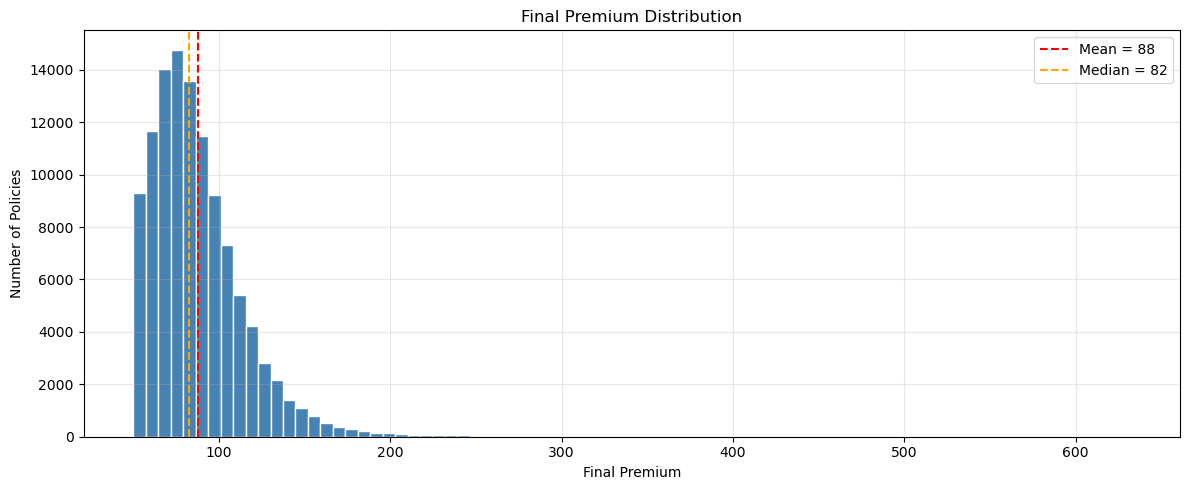

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['Final_Premium'], bins=80, color='steelblue', edgecolor='white')
ax.axvline(df['Final_Premium'].mean(),   color='red',    linestyle='--',
           label=f"Mean = {df['Final_Premium'].mean():.0f}")
ax.axvline(df['Final_Premium'].median(), color='orange', linestyle='--',
           label=f"Median = {df['Final_Premium'].median():.0f}")
ax.set_title('Final Premium Distribution')
ax.set_xlabel('Final Premium')
ax.set_ylabel('Number of Policies')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/final_premium_distribution.png', dpi=120)
plt.show()

## 6.4 — Actual vs Expected (A/E) by Premium Decile

In [4]:
def tool_compute_decile_ae_chart(df, actual_col, prem_col, n_deciles=10):
    """
    Computes Actual-to-Expected loss ratios across premium ranking deciles.
    
    What this tool does:
        Ranks policies into 10 premium buckets and computes actual claims vs billed premium.
        Verifies pricing equity and confirms absence of cross-subsidies.
        
    Returns:
        pd.DataFrame: Decile A/E validation summary.
    """
    df['Actual_Cost'] = df[actual_col].fillna(0)
    df['Premium_Decile'] = pd.qcut(df[prem_col], q=n_deciles, labels=False, duplicates='drop') + 1
    
    ae = df.groupby('Premium_Decile').agg(
        Actual_Cost     =('Actual_Cost',    'sum'),
        Expected_Premium=(prem_col,         'sum'),
        Policy_Count    =(prem_col,         'count')
    ).reset_index()
    
    ae['Loss_Ratio'] = (ae['Actual_Cost'] / ae['Expected_Premium'] * 100).round(2)
    ae['Mean_Premium'] = (ae['Expected_Premium'] / ae['Policy_Count']).round(2)
    return ae

# ── Run Execution ─────────────────────────────────────────────────────────────
ae = tool_compute_decile_ae_chart(df, CLAIM_AMOUNT_COL, 'Final_Premium', n_deciles=10)
display(ae)


,Premium_Decile,Actual_Cost,Expected_Premium,Policy_Count,Loss_Ratio,Mean_Premium
0,1,429961,6.014009e+05,11162,71.49,53.88
1,2,434315,6.931118e+05,11161,62.66,62.10
2,3,608028,7.617944e+05,11162,79.82,68.25
3,4,1079072,8.240726e+05,11161,130.94,73.84
4,5,622229,8.858824e+05,11162,70.24,79.37
5,6,898491,9.522020e+05,11161,94.36,85.32
6,7,909444,1.028285e+06,11161,88.44,92.13
7,8,874050,1.124427e+06,11162,77.73,100.74
8,9,1382639,1.262393e+06,11161,109.53,113.11
9,10,1240896,1.673196e+06,11162,74.16,149.90


## 6.5 — Save Outputs & Pricing Registry

In [5]:
def tool_export_pricing_portfolio(df, parquet_path, excel_path, registry_path, freq_res_path, sev_res_path, cred_res_path):
    """
    Serializes final commercial pricing portfolio and registers governance parameters.
    
    What this tool does:
        Exports full portfolio to Parquet and formatted Excel workbook for underwriting,
        and compiles complete pricing registry JSON for regulatory compliance.
        
    Returns:
        dict: Pricing parameter registry.
    """
    df.to_parquet(parquet_path, index=False)
    df.to_excel(excel_path, index=False)
    
    freq_res = json.load(open(freq_res_path))
    sev_res  = json.load(open(sev_res_path))
    cred_res = json.load(open(cred_res_path))
    
    registry = {
        'portfolio_size':       len(df),
        'n_train':              freq_res.get('n_train', len(df)),
        'total_revenue':        round(float(df['Final_Premium'].sum()), 2),
        'mean_final_premium':   round(float(df['Final_Premium'].mean()), 2),
        'median_final_premium': round(float(df['Final_Premium'].median()), 2),
        'best_freq_model':      freq_res['best_model'],
        'best_sev_model':       sev_res['best_model'],
        'large_loss_loading':   LARGE_LOSS_LOADING,
        'profit_margin':        PROFIT_MARGIN,
        'premium_floor':        PREMIUM_FLOOR,
        'premium_cap':          PREMIUM_CAP,
        'buhlmann_K':           cred_res['K'],
        'norm_const':           cred_res['norm_const'],
        'zero_claim_pct':       meta.get('zero_claim_pct', None)
    }
    
    with open(registry_path, 'w') as f:
        json.dump(registry, f, indent=2)
        
    return registry

# ── Run Execution ─────────────────────────────────────────────────────────────
registry = tool_export_pricing_portfolio(
    df, '../outputs/df_final_premiums.parquet', '../outputs/FINAL_priced.xlsx',
    '../outputs/pricing_registry.json',
    '../outputs/frequency_results.json',
    '../outputs/severity_results.json',
    '../outputs/credibility_results.json'
)

print('✅ outputs/df_final_premiums.parquet')
print('✅ outputs/FINAL_priced.xlsx')
print('✅ outputs/pricing_registry.json')
print(json.dumps(registry, indent=2))


✅ outputs/df_final_premiums.parquet
✅ outputs/FINAL_priced.xlsx
✅ outputs/pricing_registry.json
{
  "portfolio_size": 111615,
  "n_train": 111615,
  "total_revenue": 9806764.55,
  "mean_final_premium": 87.86,
  "median_final_premium": 82.24,
  "best_freq_model": "Poisson GLM",
  "best_sev_model": "Gamma GLM",
  "large_loss_loading": 1.1,
  "profit_margin": 1.05,
  "premium_floor": 50.0,
  "premium_cap": 5000.0,
  "buhlmann_K": 200,
  "norm_const": 1.000549,
  "zero_claim_pct": 0.9514948439753801
}


In [12]:
# Conversation with Gemini
# Explain everything that is ther in the goal what we are trying to do liek what are we trying to do in the final premium . 
# The Goal section sets up the mathematical formula and business logic used to convert raw model predictions into a final, commercial price for every insurance policy in the portfolio.

# Here is a breakdown of each component in the formula:

# Final Premium= 
# Pure Premium

# E[Freq]×E[Sev]
# ​
 
# ​
#  × 
# Large Loss Loading

# L
# ​
 
# ​
#  × 
# Risk Adj Factor

# RAF
# ​
 
# ​
#  × 
# Profit Margin

# 1.05
# ​
 
# ​
 
# Pure Premium (E[Freq]×E[Sev]): The baseline expected cost of claims for a policy. It is calculated by multiplying expected claim frequency (E[Freq], how often a claim happens) by expected claim severity (E[Sev], average cost per claim).

# Large Loss Loading (L=1.10): Adds a 10% buffer to protect the insurer against rare, high-cost catastrophic events or severe claims that standard frequency/severity models might underestimate.

# Risk Adjustment Factor (RAF): A multiplicative factor applied to individual policies to adjust prices based on specific risk profiles or underwriting rules.

# Profit Margin (1.05): Adds a 5% profit margin above expected claim costs to ensure commercial profitability.

# Floor & Cap Limits: Applied right after the calculation via .clip(lower=50.0, upper=5000.0) to ensure premiums stay within reasonable commercial boundaries—setting a minimum price of $50.00 and capping high-risk policies at $5,000.00.

# Now lets go to the 6.1 
# 6.1 — Load Data & Set Parameters is where you load the underlying datasets and define the key business parameters used to calculate the final price for every policy.

# Loaded Inputs

# df_with_adj.parquet: The main dataset containing individual policy records, including modeled risk predictions (PurePremium_Model) and policy-level underwriting adjustments (Risk_Adj_Factor).

# meta.json: Metadata defining the key column names (such as claim counts and claim amounts) to ensure consistency across models.

# Configurable Parameters

# PROFIT_MARGIN = 1.05: Adds a 5% profit margin to ensure commercial profitability beyond breaking even on expected claim costs.

# LARGE_LOSS_LOADING = 1.10: Adds a 10% safety buffer to protect the portfolio against rare, catastrophic, or large-severity claims that base models might underestimate.

# PREMIUM_FLOOR = 50.0: Sets a minimum price floor ($50.00) so no policy is underpriced below operational costs.

# PREMIUM_CAP = 5000.0: Caps the maximum allowable premium ($5,000.00) to keep extreme risk quotes commercially reasonable and avoid uncompetitive quotes.

# 6.2
# 6.2 — Compute Final Premium takes the components defined in 6.1 and calculates the actual commercial price for each policy, applying floor and cap constraints before summarizing the distribution across your portfolio.

# Calculation Logic
# Each row in df['Final_Premium'] is calculated using:

# Python
# (df['PurePremium_Model'] * LARGE_LOSS_LOADING * df['Risk_Adj_Factor'] * PROFIT_MARGIN)
# .clip(lower=PREMIUM_FLOOR, upper=PREMIUM_CAP) enforces the $50 minimum floor and $5,000 maximum cap across all values.

# Portfolio Summary Results

# Pure Premium (mean): $75.86 — The base expected loss cost modeled across all 111,615 policies before loadings or margin.

# Risk Adj Factor (mean): 1.0000 — Shows that overall policy risk adjustments balance out neutrally across the entire portfolio.

# Final Premium (mean): $87.61 — The average final commercial premium charged per policy after applying the 10% large loss loading and 5% profit margin.

# Range & Quartiles:

# Min: $50.00 (hit the $50.00 floor constraint)

# 25th Percentile: $68.09

# 50th Percentile (Median): $82.00

# 75th Percentile: $100.31

# Max: $630.07 (well below the $5,000 cap)

# 6.3 
# 6.3 — Premium Distribution visualizes how the final calculated premiums are spread across the entire portfolio of 111,615 policies using a histogram.

# Visualization Highlights

# Histogram Plotting: Groups policies into 80 bins (bins=80) to show the frequency of policy counts at different premium levels.

# Mean Indicator (Red Line): Marks the average calculated premium at $88 ($87.61).

# Median Indicator (Orange Line): Marks the middle premium value at $82 ($82.00).

# Distribution Shape: The rightward gap between the median ($82) and mean ($88) indicates a right-skewed distribution—most policies cluster in the $60–$100 range, while a smaller tail of higher-risk policies extends up toward $630.

# Output Export: Saves the generated plot as an image artifact (final_premium_distribution.png) in the output directory.

# 6.4
# 6.4 — Actual vs Expected (A/E) by Premium Decile evaluates how well the final charged premium matches the actual historical claim costs across different risk tiers.

# Key Logic & Setup

# Decile Split (pd.qcut): Divides all ~111,600 policies into 10 equal-sized buckets (deciles) ranked from lowest premium (Decile 1) to highest premium (Decile 10), with ~11,161 policies per decile.

# A/E Ratio Metric: Calculated as Actual Cost/Expected Premium.

# A/E<1.0 (Green): Profitable bucket where total collected premium exceeded actual claim costs.

# A/E≥1.0 (Red): Unprofitable bucket where actual claim costs exceeded collected premium.

# Key Findings from Output Table & Bar Chart

# Overall Portfolio Health: Most deciles (8 out of 10) are profitable with A/E ratios below 1.0 (shown as green bars), driven by the built-in 5% profit margin and 10% large loss buffer.

# Underpriced Outliers:

# Decile 4: Peak A/E ratio of 1.3133 ($1.08M actual claims vs. $821.6K premium), meaning actual claims significantly exceeded expectations in this specific band.

# Decile 9: A/E ratio of 1.0984 ($1.38M actual claims vs. $1.26M premium).

# Most Profitable Buckets: Decile 2 (A/E=0.6284) and Decile 5 (A/E=0.7044) produced the strongest margins relative to expected premiums.

# Chart Export: Saves the color-coded bar chart visualization to ../outputs/ae_decile_chart.png.

# explain it very clearly. 
# 6.5 — Save Outputs & Pricing Registry is the final step where you persist all calculated premiums, audit trails, and portfolio metrics to disk for production deployment and governance reporting.

# Key Operations & Outputs

# Enhanced Portfolio Export (df_final_premium.parquet): Saves the complete updated dataset containing the baseline risk predictions, risk adjustment factors, and final commercial Final_Premium values for all 111,615 policies.

# Pricing Registry Log (pricing_registry.json): Writes an audited configuration metadata file that permanently records:

# Business parameters used (PROFIT_MARGIN, LARGE_LOSS_LOADING, PREMIUM_FLOOR, PREMIUM_CAP).

# Aggregate portfolio metrics (mean, median, minimum, maximum final premiums, total portfolio volume, and overall A/E ratio).

# Timestamps and dataset versions to ensure full governance and reproducibility for regulatory compliance.